## **K-Means Clustering Algorithm**

K-Means is an **unsupervised machine learning algorithm** used to **group similar data points into K clusters**.

You do **NOT** need labels (target `y`) in K-Means.

### Where it is used
- Customer segmentation
- Grouping similar products
- Document clustering
- Image compression / color quantization


## Is K-Means classification or regression?

Neither.

 **K-Means is clustering (unsupervised learning)** — it finds groups in the data without a target column.


### Steps of K-Means Algorithm

1. Choose the number of clusters **K**
2. Randomly initialize **K centroids**
3. Assign each data point to the **closest centroid**
4. Recalculate centroids (mean of points in each cluster)
5. Repeat steps 3–4 until centroids stop changing (converges)

he goal is to minimize **within-cluster distance** (inertia).


A **centroid** is the **center point of a cluster**.
When K-Means makes a group (cluster) of points, it finds the **average location** of all points in that group.
That average point is called the **centroid**.

## example

Suppose a cluster has 3 points:

* (1, 1)
* (2, 2)
* (3, 3)

Centroid = average of x values and y values:

* x̄ = (1 + 2 + 3) / 3 = 2
* ȳ = (1 + 2 + 3) / 3 = 2

Centroid = (2, 2)

**Centroid = the “mean point” (average point) of a cluster.**


# **K-Means Clustering Example**



We have 6 data points in 2D:

| Point | (x, y) |
|------|--------|
| P1 | (1, 1) |
| P2 | (1.5, 2) |
| P3 | (3, 4) |
| P4 | (5, 7) |
| P5 | (3.5, 5) |
| P6 | (4.5, 5) |

We choose **K = 2** (2 clusters).

---

#  Step 1: Initialize Centroids (Randomly)
Let’s choose:

- **C1 = P1 = (1, 1)**
- **C2 = P4 = (5, 7)**

---

#  Step 2: Compute Distance of Each Point to Each Centroid

We use Euclidean distance:



$$
d(A,B) = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2 + \ldots )}
$$



### Distances:

### **Point P1 = (1,1)**
- d(P1, C1) = √((1-1)² + (1-1)²) = √0 = **0**
- d(P1, C2) = √((1-5)² + (1-7)²) = √(16+36)= √52 = **7.21**
 Assign P1 → Cluster 1

---

### **Point P2 = (1.5,2)**
- d(P2, C1) = √((1.5-1)² + (2-1)²) = √(0.25+1)= √1.25 = **1.12**
- d(P2, C2) = √((1.5-5)² + (2-7)²) = √(12.25+25)= √37.25 = **6.10**
Assign P2 → Cluster 1

---

### **Point P3 = (3,4)**
- d(P3, C1) = √((3-1)² + (4-1)²) = √(4+9)= √13 = **3.61**
- d(P3, C2) = √((3-5)² + (4-7)²) = √(4+9)= √13 = **3.61**
 Tie → choose any (let’s put it in Cluster 1 for now)

---

### **Point P4 = (5,7)**
- d(P4, C1) = √((5-1)² + (7-1)²) = √(16+36)= √52 = **7.21**
- d(P4, C2) = √((5-5)² + (7-7)²) = **0**
 Assign P4 → Cluster 2

---

### **Point P5 = (3.5,5)**
- d(P5, C1) = √((3.5-1)² + (5-1)²) = √(6.25+16)= √22.25 = **4.72**
- d(P5, C2) = √((3.5-5)² + (5-7)²) = √(2.25+4)= √6.25 = **2.50**
 Assign P5 → Cluster 2

---

### **Point P6 = (4.5,5)**
- d(P6, C1) = √((4.5-1)² + (5-1)²) = √(12.25+16)= √28.25 = **5.31**
- d(P6, C2) = √((4.5-5)² + (5-7)²) = √(0.25+4)= √4.25 = **2.06**
Assign P6 → Cluster 2

---

# Step 3: New Clusters After 1st Assignment

### Cluster 1:
P1 (1,1), P2 (1.5,2), P3 (3,4)

### Cluster 2:
P4 (5,7), P5 (3.5,5), P6 (4.5,5)

---

# Step 4: Recalculate New Centroids (Mean of Points)

### New C1:
\[
C1 = \left(\frac{1+1.5+3}{3}, \frac{1+2+4}{3}\right)
= (1.83, 2.33)
\]

### New C2:
\[
C2 = \left(\frac{5+3.5+4.5}{3}, \frac{7+5+5}{3}\right)
= (4.33, 5.67)
\]

---

#  Step 5: Repeat Steps 2–4
Now again compute distances using new centroids.
If clusters stop changing → **K-Means has converged**

---

##  Final Idea
K-Means keeps doing:
 Assign points →  Update centroids → Repeat  
until centroids do not change anymore.


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
# ✅ Load iris dataset (we will ignore the true labels for clustering)
iris = load_iris(as_frame=True)
df = iris.frame.copy()

# We'll pick 2 features for easy 2D visualization
X = df[["sepal length (cm)", "sepal width (cm)"]]

X.head()


,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


## Preprocessing (Scaling)
K-Means depends on distances, so scaling is important.

In [ ]:
numeric_features = X.columns.tolist()
categorical_features = []  # iris example has no categorical features

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['sepal length (cm)', 'sepal width (cm)']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 [])])

## Train K-Means Model

In [ ]:
k = 3  # we choose 3 clusters (iris has 3 species, but in clustering we don't use labels)
kmeans_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("kmeans", KMeans(n_clusters=k, random_state=42, n_init="auto"))
])

kmeans_pipeline.fit(X)

# Cluster labels predicted by K-Means
clusters = kmeans_pipeline.named_steps["kmeans"].labels_

print("Cluster labels (first 10):", clusters[:10])


Cluster labels (first 10): [2 2 2 2 2 2 2 2 2 2]


## Visualize Clusters (2D)

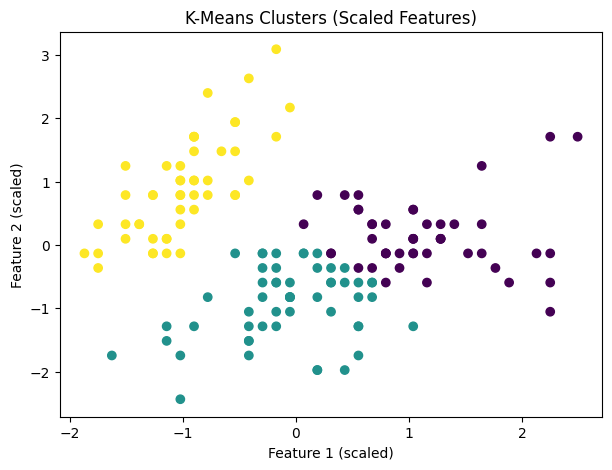

In [ ]:
# Transform data so we can plot scaled points
X_scaled = kmeans_pipeline.named_steps["preprocessor"].transform(X)

plt.figure(figsize=(7,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.title("K-Means Clusters (Scaled Features)")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()


## Centroids Visualization

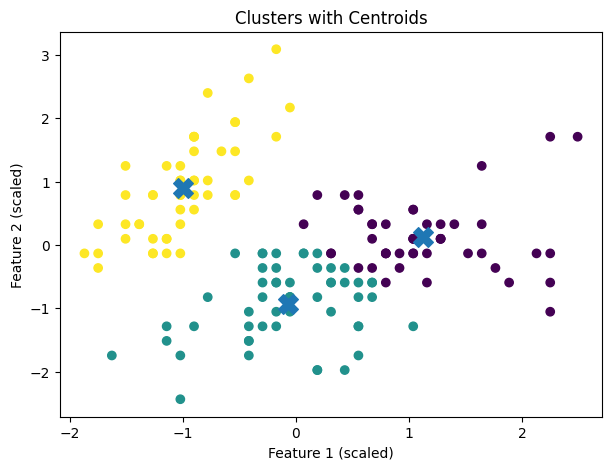

In [ ]:
centroids = kmeans_pipeline.named_steps["kmeans"].cluster_centers_

plt.figure(figsize=(7,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=200)
plt.title("Clusters with Centroids")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()


# **How to Choose the Value of K in K-Means**

Two common methods:
1) **Elbow Method** (uses inertia)
2) **Silhouette Score**

## Elbow Method

When we use **K-Means**, we must choose the number of clusters **K**.  
But K is not given automatically — so we use methods to find a good K.

###  What Elbow Method does
Elbow method checks **how good clustering is** for different values of K.

K-Means tries to minimize **Inertia**.

**Inertia** = total squared distance of each point from its cluster centroid  
(so smaller inertia = tighter clusters)

### Steps
1. Run K-Means for K = 1, 2, 3, 4, ...  
2. For each K, calculate inertia
3. Plot **K vs Inertia**

### Interpretation
- When K increases, inertia always decreases (because more clusters = easier to fit points)
- But after some point, improvement becomes **very small**
- That point looks like an **elbow (bend)** in the graph

 The K at the elbow is usually the best choice.

### Why it is called "Elbow"?
Because the graph looks like an arm and the bend is the elbow.

---

## Silhouette Score (Easy Explanation)

Silhouette score is another way to decide the best K.

It checks **two things together**:

### 1) How close a point is to its own cluster (good)
This is called **a**

### 2) How far a point is from other clusters (good)
This is called **b**

Silhouette score formula:

\[
s = \frac{b-a}{\max(a,b)}
\]

### Range of Silhouette Score
- **+1** → Perfect clustering (point is well inside its cluster)
- **0** → Overlapping clusters
- **-1** → Wrong clustering (point is closer to another cluster)

### Steps
1. Try different K values (2 to 10 usually)
2. Compute silhouette score for each K
3. The **highest silhouette score** gives the best K



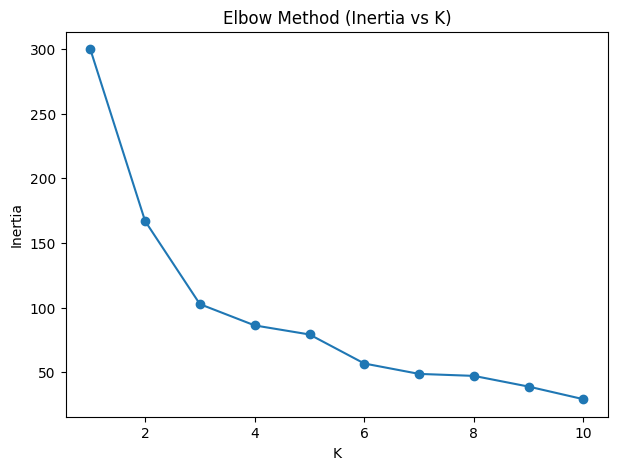

In [ ]:
# ✅ Elbow Method: try different K and record inertia
inertias = []
K_values = range(1, 11)

for k in K_values:
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("kmeans", KMeans(n_clusters=k, random_state=42, n_init="auto"))
    ])
    pipe.fit(X)
    inertias.append(pipe.named_steps["kmeans"].inertia_)

plt.figure(figsize=(7,5))
plt.plot(list(K_values), inertias, marker="o")
plt.title("Elbow Method (Inertia vs K)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()


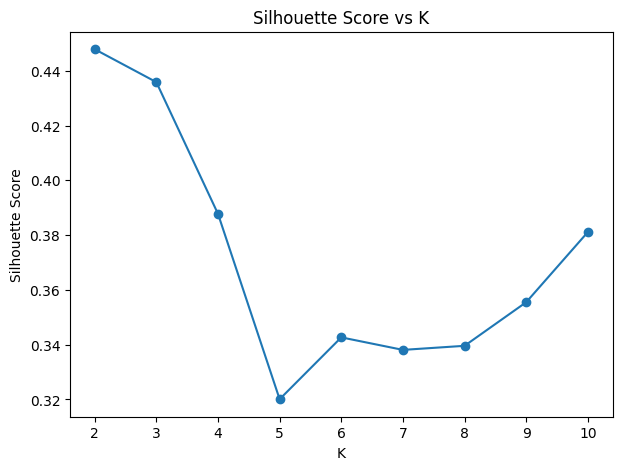

Best K by silhouette (for this 2D example): 2


In [ ]:
# ✅ Silhouette Score (higher is better, range roughly -1 to +1)
sil_scores = []
K_values = range(2, 11)  # silhouette requires at least 2 clusters

for k in K_values:
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("kmeans", KMeans(n_clusters=k, random_state=42, n_init="auto"))
    ])
    pipe.fit(X)
    labels = pipe.named_steps["kmeans"].labels_
    X_scaled_tmp = pipe.named_steps["preprocessor"].transform(X)
    sil = silhouette_score(X_scaled_tmp, labels)
    sil_scores.append(sil)

plt.figure(figsize=(7,5))
plt.plot(list(K_values), sil_scores, marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.show()

best_k = list(K_values)[int(np.argmax(sil_scores))]
print("Best K by silhouette (for this 2D example):", best_k)


# Limitations of K-Means Algorithm

- Must choose **K** first
- Works best when clusters are roughly **round / spherical**
- Sensitive to **outliers**
- Different initial centroids can change results (that’s why we use `random_state` and multiple initializations)
- Not good for non-linear cluster shapes
